<a href="https://colab.research.google.com/github/marina-popova11/Homework-1/blob/main/mamba_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch
!pip install pandas numpy scikit-learn tqdm torch matplotlib
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.1 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl size=533592144 sha256=d66a3c4c94a693e02d341cace7a6af0b72177b6afa655a25e3a6505130a68cbf
  Stored in directory: /root/.cache/pip/wheels/28/83/54/d45107838fec575b93f5d723f56351cee19a1b13bcd4ec9f3f
Successfully built mamba-ssm


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm
import pickle
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_data_internal(df, lookback=60):
    df = df.sort_values('Open time').reset_index(drop=True)
    df['Open time'] = pd.to_datetime(df['Open time'])

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Quote asset volume', 'Number of trades',
        'Taker buy base asset volume', 'Taker buy quote asset volume',
        'returns', 'log_return', 'volatility',
        'sma_12', 'sma_24', 'ema_12', 'rsi',
        'volume_ma', 'volume_ratio'
    ]

    target_col = 'target_return'
    df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

    total_len = len(df)
    train_end = int(total_len * 0.70)
    val_end = int(total_len * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    scaler_features = RobustScaler(quantile_range=(10.0, 90.0))# StandardScaler()
    scaler_target = StandardScaler()

    scaler_features.fit(train_df[feature_cols])
    scaler_target.fit(train_df[[target_col]])

    def scale_split(df_split):
        df_scaled = df_split.copy()
        df_scaled[feature_cols] = scaler_features.transform(df_split[feature_cols])
        df_scaled[[target_col]] = scaler_target.transform(df_split[[target_col]])
        return df_scaled

    train_scaled = scale_split(train_df)
    val_scaled = scale_split(val_df)
    test_scaled = scale_split(test_df)

    def create_windows(df_part):
        X, y = [], []
        for i in range(lookback, len(df_part)):
            X.append(df_part[feature_cols].iloc[i-lookback:i].values)
            y.append(df_part[target_col].iloc[i])
        return np.array(X), np.array(y).reshape(-1, 1).astype(np.float32)

    X_train, y_train = create_windows(train_scaled)
    X_val, y_val = create_windows(val_scaled)
    X_test, y_test = create_windows(test_scaled)

    time_train = train_scaled['Open time'].iloc[lookback:].values
    time_val = val_scaled['Open time'].iloc[lookback:].values
    time_test = test_scaled['Open time'].iloc[lookback:].values

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler_features': scaler_features,
        'scaler_target': scaler_target,
        'feat_cols': feature_cols,
        'time_index': {'train': time_train, 'val': time_val, 'test': time_test}
    }

In [4]:
def get_data_loaders(filename, lookback=60, batch_size=128, cache_file='data_cache.pkl'):
    if os.path.exists(cache_file):
        print(f"Загрузка кэшированных данных из {cache_file}...")
        with open(cache_file, 'rb') as f:
            data_dict = pickle.load(f)
    else:
        print(f"Обработка данных из {filename} (это займет время)...")
        df = pd.read_csv(filename)
        data_dict = prepare_data_internal(df, lookback)

        with open(cache_file, 'wb') as f:
            pickle.dump(data_dict, f)
        print(f"Кэш сохранен в {cache_file}")

    def make_loader(X, y, shuffle=False):
        dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(data_dict['X_train'], data_dict['y_train'], shuffle=True)
    val_loader = make_loader(data_dict['X_val'], data_dict['y_val'], shuffle=False)
    test_loader = make_loader(data_dict['X_test'], data_dict['y_test'], shuffle=False)

    print(f"Данные готовы: Train={len(data_dict['X_train'])}, Val={len(data_dict['X_val'])}, Test={len(data_dict['X_test'])}")

    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'scaler_target': data_dict['scaler_target'],
        'feat_cols': data_dict['feat_cols'],
        'time_index': data_dict['time_index']
    }

In [ ]:
# # mamba для бинарной
# class MambaModel(nn.Module):
#     def __init__(self, input_dim, d_model=128, n_layers=2, use_mamba=True):
#         super().__init__()
#         self.use_mamba = use_mamba
#         self.input_proj = nn.Linear(input_dim, d_model)

#         if use_mamba:
#             try:
#                 from mamba_ssm import Mamba
#                 print("Using Mamba Architecture")
#                 self.blocks = nn.ModuleList([
#                     Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
#                     for _ in range(n_layers)
#                 ])
#             except ImportError:
#                 print("Mamba not installed. Falling back to LSTM.")
#                 self.use_mamba = False

#         if not self.use_mamba:
#             print("Using LSTM Architecture (Fallback)")
#             self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model,
#                                num_layers=n_layers, batch_first=True, dropout=0.0)

#         self.norm = nn.LayerNorm(d_model)
#         self.head = nn.Sequential(
#             nn.Linear(d_model, 64),
#             nn.GELU(),
#             nn.Dropout(0.1),
#             nn.Linear(64, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         x = self.input_proj(x)

#         if self.use_mamba:
#             for block in self.blocks:
#                 x = block(x)
#         else:
#             x, _ = self.lstm(x)

#         x = x.mean(dim=1)

#         x = self.norm(x)
#         return self.head(x)

In [5]:
class MambaModel(nn.Module):
    def __init__(self, input_dim, d_model=128, n_layers=3, use_mamba=True):
        super().__init__()
        self.use_mamba = use_mamba
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)
        self.input_proj = nn.Linear(input_dim, d_model)

        if use_mamba:
            try:
                from mamba_ssm import Mamba
                print("Using Mamba Architecture")
                self.blocks = nn.ModuleList([
                    Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
                    for _ in range(n_layers)
                ])
            except ImportError:
                print("Mamba not installed. Falling back to LSTM.")
                self.use_mamba = False

        if not self.use_mamba:
            print("Using LSTM Architecture (Fallback)")
            self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model, num_layers=n_layers, batch_first=True, dropout=0.0)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.drop1(x)
        if self.use_mamba:
            for block in self.blocks:
                x = block(x)
        else:
            x, _ = self.lstm(x)
        x = self.drop2(x)
        x = self.norm(x)
        last_hidden = x[:, -1, :] # last_hidden = x.mean(dim=1)
        return self.head(last_hidden)

In [ ]:
# # для бинарной задачи

# def run_training(model, data_dict, epochs=10, learning_rate=1e-4, early_stop_patience=10, model_path="best_mamba_model.pth"): #learning_rate=3e-4
#     train_loader = data_dict['train_loader']
#     val_loader = data_dict['val_loader']

#     criterion = nn.BCELoss()
#     optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

#     best_val_loss = float('inf')
#     patience_counter = 0
#     history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

#     print("\nStarting Training Loop...")
#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0.0
#         train_preds = []
#         train_targets = []
#         for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
#             xb, yb = xb.to(device), yb.to(device)
#             optimizer.zero_grad()
#             preds = model(xb)
#             loss = criterion(preds, yb)

#             if torch.isnan(loss) or torch.isinf(loss):
#                 print(f"DETECTED NaN/Inf Loss! Stopping.")
#                 return history

#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
#             train_loss += loss.item()
#             train_preds.extend(preds.detach().cpu().numpy())
#             train_targets.extend(yb.cpu().numpy())

#         train_loss /= len(train_loader)
#         train_preds_binary = (np.array(train_preds) > 0.5).astype(int)
#         train_targets_binary = np.array(train_targets).astype(int)
#         train_acc = np.mean(train_preds_binary == train_targets_binary)

#         history['train_loss'].append(train_loss)
#         history['train_acc'].append(train_acc)

#         # Validation
#         model.eval()
#         val_loss = 0.0
#         val_preds = []
#         val_targets = []
#         with torch.no_grad():
#             for xb, yb in val_loader:
#                 xb, yb = xb.to(device), yb.to(device)
#                 preds = model(xb)
#                 loss = criterion(preds, yb)
#                 val_loss += loss.item()
#                 val_preds.extend(preds.cpu().numpy())
#                 val_targets.extend(yb.cpu().numpy())
#         val_loss /= len(val_loader)
#         val_preds_binary = (np.array(val_preds) > 0.5).astype(int)
#         val_targets_binary = np.array(val_targets).astype(int)
#         val_acc = np.mean(val_preds_binary == val_targets_binary)
#         history['val_loss'].append(val_loss)
#         history['val_acc'].append(val_acc)

#         current_lr = optimizer.param_groups[0]['lr']
#         print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f} | "
#               f"Train Acc={train_acc:.2%}, Val Acc={val_acc:.2%}, LR={current_lr:.2e}")
#         scheduler.step(val_loss)

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             torch.save(model.state_dict(), model_path)
#             print("-> Saved new best model!")
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             if patience_counter >= early_stop_patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break

#     return history

In [ ]:
# # mamba binary test
# def evaluate_model(model, data_dict, model_path="best_binary_model.pth"):
#     test_loader = data_dict['test_loader']
#     time_index_raw = data_dict['time_index']

#     if isinstance(time_index_raw, dict):
#         test_time = time_index_raw['test']
#     else:
#         test_len = len(data_dict['test_loader'].dataset)
#         test_time = time_index_raw.iloc[-test_len:].values

#     print("\nEvaluating on Test Set...")
#     model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
#     model.eval()

#     all_preds_prob = []
#     all_targets = []

#     with torch.no_grad():
#         for xb, yb in test_loader:
#             xb = xb.to(device)
#             preds = model(xb).squeeze(-1).cpu().numpy()
#             all_preds_prob.extend(preds)
#             all_targets.extend(yb.squeeze(-1).numpy())

#     all_preds_prob = np.array(all_preds_prob)
#     all_targets = np.array(all_targets)

#     # Бинарные предсказания (порог 0.5)
#     predicted_classes = (all_preds_prob > 0.5).astype(int)

#     # Метрики
#     accuracy = np.mean(predicted_classes == all_targets)

#     from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

#     f1 = f1_score(all_targets, predicted_classes)
#     precision = precision_score(all_targets, predicted_classes)
#     recall = recall_score(all_targets, predicted_classes)

#     print(f"\n{'='*50}")
#     print(f"BINARY CLASSIFICATION RESULTS")
#     print(f"{'='*50}")
#     print(f"Accuracy:  {accuracy:.2%}")
#     print(f"Precision: {precision:.2%}")
#     print(f"Recall:    {recall:.2%}")
#     print(f"F1-Score:  {f1:.4f}")
#     print(f"\nConfusion Matrix:")
#     print(confusion_matrix(all_targets, predicted_classes))
#     print(f"\nClassification Report:")
#     print(classification_report(all_targets, predicted_classes, target_names=['Down (0)', 'Up (1)']))
#     print(f"{'='*50}")

#     # График
#     plt.figure(figsize=(14, 6))

#     # Подграфик 1: Вероятности
#     plt.subplot(2, 1, 1)
#     plt.plot(test_time, all_targets, label='Actual (1=Up)', color='blue', alpha=0.3, linewidth=1)
#     plt.plot(test_time, all_preds_prob, label='Predicted Probability', color='red', alpha=0.8, linewidth=1)
#     plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Threshold 0.5')
#     plt.title(f'Binary Classification Results (Accuracy: {accuracy:.2%})')
#     plt.ylabel('Probability / Class')
#     plt.legend(loc='upper right')
#     plt.grid(True, alpha=0.3)

#     # Подграфик 2: Cumulative Returns (стратегия)
#     plt.subplot(2, 1, 2)
#     # Стратегия: покупаем если предсказан рост (prob > 0.5)
#     strategy_returns = predicted_classes * np.sign(np.concatenate([[0], np.diff(all_targets)]))
#     # Или проще: стратегия следует за предсказаниями
#     cumulative_strategy = np.cumsum(predicted_classes - 0.5)  # Центрируем
#     cumulative_buyhold = np.cumsum(all_targets - 0.5)

#     plt.plot(test_time, cumulative_strategy, label='Strategy (Model)', color='red', linewidth=1.5)
#     plt.plot(test_time, cumulative_buyhold, label='Buy & Hold', color='blue', linewidth=1.5, alpha=0.5)
#     plt.title('Cumulative Returns (Simplified)')
#     plt.xlabel('Date')
#     plt.ylabel('Cumulative Return')
#     plt.legend()
#     plt.grid(True, alpha=0.3)

#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.savefig('binary_results.png', dpi=150, bbox_inches='tight')
#     plt.show()

#     return {
#         'accuracy': accuracy,
#         'f1': f1,
#         'precision': precision,
#         'recall': recall,
#         'preds_prob': all_preds_prob,
#         'preds_classes': predicted_classes,
#         'targets': all_targets,
#         'time': test_time
#     }

In [6]:
def run_training(model, data_dict, epochs=20, learning_rate=3e-4, early_stop_patience=10, model_path="best_mamba_model.pth"): #learning_rate=3e-4
    train_loader = data_dict['train_loader']
    val_loader = data_dict['val_loader']

    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5) #lr=learning_rate, weight_decay=1e-3
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    print("\nStarting Training Loop...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"DETECTED NaN/Inf Loss! Stopping.")
                return None

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.6f}, Val={val_loss:.6f}")
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            print("-> Saved new best model!")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return history

In [7]:
def evaluate_model(model, data_dict, lookback, model_path="best_mamba_model2.pth"):
    test_loader = data_dict['test_loader']
    scaler_target = data_dict['scaler_target']
    time_index_raw = data_dict['time_index']
    if isinstance(time_index_raw, dict):
        test_time = time_index_raw['test']
    else:
        test_len = len(data_dict['test_loader'].dataset)
        test_time = time_index_raw.iloc[-test_len:].values

    print("\nEvaluating on Test Set...")
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = model(xb).squeeze(-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.squeeze(-1).numpy())

    all_preds = np.array(all_preds).reshape(-1, 1)
    all_targets = np.array(all_targets).reshape(-1, 1)

    preds_real = scaler_target.inverse_transform(all_preds).flatten()
    targets_real = scaler_target.inverse_transform(all_targets).flatten()

    pred_direction = np.sign(preds_real)
    true_direction = np.sign(targets_real)
    accuracy = np.mean(pred_direction == true_direction)

    rmse = math.sqrt(mean_squared_error(targets_real, preds_real))
    mae = np.mean(np.abs(targets_real - preds_real))

    print(f"\nРезультаты: RMSE={rmse:.6f}, MAE={mae:.6f}, Accuracy={accuracy:.2%}")
    # total_len = len(time_index)
    # test_start_idx = int(total_len * 0.85) + lookback

    # plot_time = time_index.iloc[test_start_idx:test_start_idx+len(targets_real)]

    plt.figure(figsize=(14, 5))
    plt.plot(test_time, targets_real, label='Actual', color='blue', alpha=0.7)
    plt.plot(test_time, preds_real, label='Predicted', color='red', alpha=0.7, linestyle='--')
    plt.title(f'Test Results (Accuracy: {accuracy:.2%})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('mamba_results2.png', dpi=150)
    plt.show()

    return {
        'rmse': rmse,
        'mae': mae,
        'accuracy': accuracy,
        'preds': preds_real,
        'targets': targets_real,
        'time': test_time
    }

Обработка данных из btc_1h_2020-2025_kotirovki_24h.csv (это займет время)...
Кэш сохранен в processed_data_cache.pkl
Данные готовы: Train=36194, Val=7662, Test=7662
Using Mamba Architecture

Starting Training Loop...


Epoch 1/20: 100%|██████████| 566/566 [00:08<00:00, 68.19it/s]


Epoch 1: Train=0.349757, Val=0.250979
-> Saved new best model!


Epoch 2/20: 100%|██████████| 566/566 [00:07<00:00, 76.58it/s]


Epoch 2: Train=0.349042, Val=0.267488


...

Epoch 9: Train=0.330979, Val=0.374235


Epoch 10/20: 100%|██████████| 566/566 [00:08<00:00, 69.84it/s]


Epoch 10: Train=0.326926, Val=0.331637


Epoch 11/20: 100%|██████████| 566/566 [00:08<00:00, 69.12it/s]


Epoch 11: Train=0.322400, Val=0.299922
Early stopping at epoch 11

Evaluating on Test Set...

Результаты: RMSE=0.022580, MAE=0.016116, Accuracy=49.09%


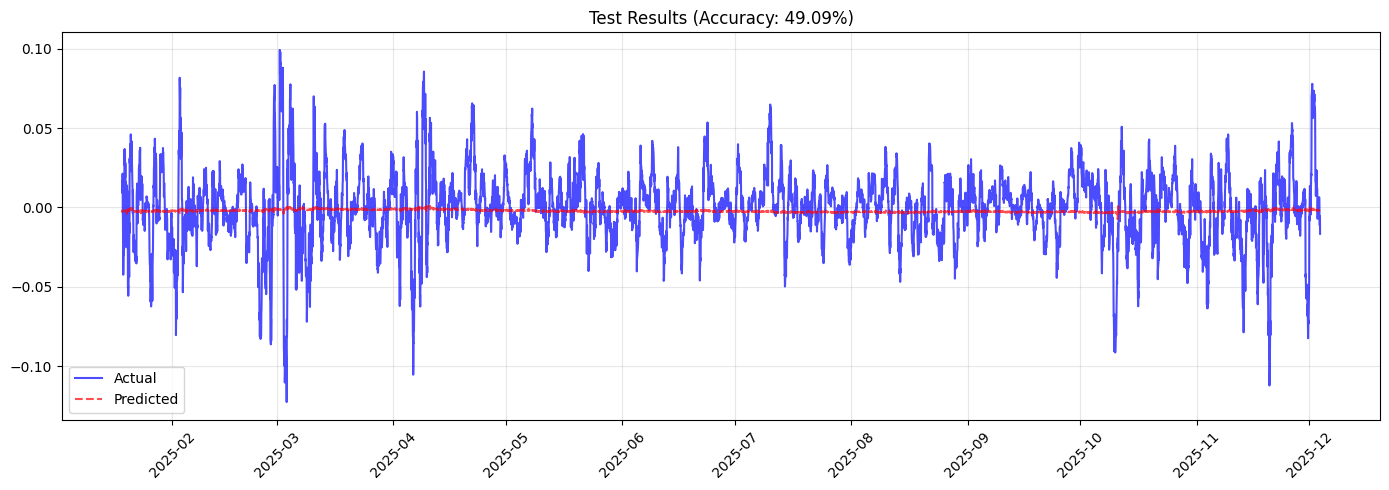

In [8]:
if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 64
    EPOCHS = 20
    D_MODEL = 128
    N_LAYERS = 2
    CSV_FILE = 'btc_1h_2020-2025_kotirovki_24h.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_model2.pth'

    data_dict = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE
    )

    model = MambaModel(input_dim=len(data_dict['feat_cols']), d_model=D_MODEL, n_layers=N_LAYERS).to(device)
    run_training(
        model=model,
        data_dict=data_dict,
        epochs=EPOCHS,
        model_path=MODEL_PATH
    )

    results = evaluate_model(
        model=model,
        data_dict=data_dict,
        lookback=LOOKBACK,
        model_path=MODEL_PATH
    )

In [ ]:
if __name__ == "__main__":
    LOOKBACK = 60
    BATCH_SIZE = 64
    EPOCHS = 10
    D_MODEL = 128
    N_LAYERS = 2
    CSV_FILE = 'btc_1h_2020-2025_kotirovki.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_model1.pth'

    # 1. Загрузка данных (из CSV или Кэша)
    # При втором запуске скрипта загрузка будет мгновенной из pickle
    data_dict = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE
    )

    model = MambaModel(input_dim=len(data_dict['feat_cols']), d_model=D_MODEL, n_layers=N_LAYERS).to(device)
    run_training(
        model=model,
        data_dict=data_dict,
        epochs=EPOCHS,
        model_path=MODEL_PATH
    )
    evaluate_model(
        model=model,
        data_dict=data_dict,
        lookback=LOOKBACK,
        model_path=MODEL_PATH
    )